<a href="https://colab.research.google.com/github/Omara455/Machine-Learning-Journey/blob/main/Student_Scores_SVR_(Categorical_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Regression (SVR)

## Importing the libraries

In [346]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [347]:
dataset = pd.read_csv('student_scores_cat.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [348]:
print(X)

[[1.7 8.8 52.3 5.8 'group']
 [8.0 7.4 71.6 3.9 'solo']
 [4.9 4.3 49.3 7.6 'tutor']
 [7.5 5.5 83.0 2.4 'group']
 [9.8 7.0 87.1 2.7 'solo']
 [5.8 5.2 41.9 4.2 'group']
 [5.5 8.8 69.3 4.4 'solo']
 [1.6 8.7 83.8 2.9 'group']
 [3.4 8.2 93.6 9.3 'solo']
 [5.5 6.4 55.1 8.5 'solo']
 [7.1 8.2 49.3 2.0 'tutor']
 [8.2 4.7 88.2 4.3 'solo']
 [4.4 5.5 90.0 3.1 'group']
 [1.6 6.3 50.9 5.1 'solo']
 [3.6 7.7 64.3 3.5 'solo']
 [9.2 6.4 79.6 5.5 'group']
 [2.9 4.7 86.5 9.3 'group']
 [5.1 5.7 49.3 4.4 'tutor']
 [9.4 5.6 76.6 6.9 'group']
 [1.2 5.5 84.4 6.4 'solo']
 [6.4 4.8 70.2 7.8 'tutor']
 [9.6 6.1 49.1 1.6 'solo']
 [3.1 6.2 42.0 7.7 'solo']
 [5.9 7.9 55.5 9.5 'group']
 [9.2 8.0 84.4 6.4 'solo']
 [2.2 6.6 42.5 3.6 'solo']
 [5.7 6.3 40.5 7.1 'tutor']
 [7.8 7.9 59.9 7.4 'solo']
 [7.0 8.4 43.5 6.9 'tutor']
 [5.2 7.4 48.2 2.3 'group']
 [2.8 8.0 41.3 9.8 'solo']
 [5.4 8.7 68.9 9.6 'solo']
 [4.4 4.2 78.3 4.8 'solo']
 [5.3 8.4 63.5 6.3 'tutor']
 [4.3 5.4 47.4 1.4 'solo']
 [8.5 6.4 58.2 9.9 'solo']
 [7.9 8.0 7

In [349]:
print(y)

[26.1 43.4 20.  44.5 50.5 21.4 37.3 47.1 42.4 20.6 34.3 44.8 42.2 20.
 35.9 41.8 36.2 21.1 41.  33.8 31.3 26.3 20.  24.1 43.8 23.2 20.  35.4
 26.  24.9 20.  31.2 36.3 35.  20.  27.5 41.6 42.8 38.1 29.9 20.  43.9
 46.4 36.6 37.  44.6 38.  53.9 20.  24.8 20.  23.1 39.6 20.  29.4 20.
 30.3 31.1 24.6 33.7]


In [350]:
y = y.reshape(len(y),1)
print(y)

[[26.1]
 [43.4]
 [20. ]
 [44.5]
 [50.5]
 [21.4]
 [37.3]
 [47.1]
 [42.4]
 [20.6]
 [34.3]
 [44.8]
 [42.2]
 [20. ]
 [35.9]
 [41.8]
 [36.2]
 [21.1]
 [41. ]
 [33.8]
 [31.3]
 [26.3]
 [20. ]
 [24.1]
 [43.8]
 [23.2]
 [20. ]
 [35.4]
 [26. ]
 [24.9]
 [20. ]
 [31.2]
 [36.3]
 [35. ]
 [20. ]
 [27.5]
 [41.6]
 [42.8]
 [38.1]
 [29.9]
 [20. ]
 [43.9]
 [46.4]
 [36.6]
 [37. ]
 [44.6]
 [38. ]
 [53.9]
 [20. ]
 [24.8]
 [20. ]
 [23.1]
 [39.6]
 [20. ]
 [29.4]
 [20. ]
 [30.3]
 [31.1]
 [24.6]
 [33.7]]


## Encoding Categorical Data

In [351]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [4])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

## Splitting Data

In [352]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

## Feature Scaling

In [353]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train[:, 3:] = sc_X.fit_transform(X_train[:, 3:])
X_test[:, 3:] = sc_X.transform(X_test[:, 3:]) # we use fit_transform calculate the feature scaling equation and transform to use the equation and feature scale aka transform
y_train = sc_y.fit_transform(y_train) # we didnt use LabelEncoder as dependent variable is categorical
y_test = sc_y.transform(y_test)

In [354]:
print(X_train)

[[1.0 0.0 0.0 -0.3102455907682675 1.0204166678283833 0.3849201659913174
  -0.19842511095212764]
 [1.0 0.0 0.0 0.864317997943147 -0.8305717063719381 0.9238320348646378
  -1.2566923693634737]
 [0.0 0.0 1.0 0.10924140520009486 -0.2610368220026085 -1.4870894837791642
  0.6563292131493439]
 [0.0 1.0 0.0 1.0321127963304921 0.9492248072822173 0.3281926008467574
  1.185462842355017]
 [0.0 1.0 0.0 1.7452406894767079 -0.4034205430949411 -0.9992324235359477
  -1.5823130642592724]
 [0.0 0.0 1.0 0.6965231995558019 1.0916085283745491 -0.9878869105070359
  -1.419502716811373]
 [0.0 1.0 0.0 0.5287284011684572 0.023730620182056586 1.3265977473910138
  1.0633550817690924]
 [0.0 1.0 0.0 -1.7784500766575357 -0.8305717063719381 1.0032506260670222
  0.37141110511552033]
 [0.0 1.0 0.0 0.6126258003621298 1.0204166678283833 1.3776525560211181
  0.37141110511552033]
 [0.0 1.0 0.0 -1.5267578790765184 -1.4712984512874343 -0.3922474764891554
  -0.7682613270197755]
 [0.0 0.0 1.0 -0.14245079238092279 -0.688187985279

In [355]:
print(y_test)

[[-0.32989921]
 [ 1.13728986]
 [-1.36741148]
 [-1.36741148]
 [-1.36741148]
 [ 0.41417525]
 [ 0.20457681]
 [-0.58141734]
 [-1.36741148]
 [ 0.2464965 ]
 [ 1.12680994]
 [-1.36741148]]


## Training the SVR model on the whole dataset

In [356]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

## Predicting a new result

In [357]:
y_pred = sc_y.inverse_transform(regressor.predict(X_test).reshape(-1,1))
print(y_pred)

y_pred = y_pred.flatten()
df_comparison = pd.DataFrame({ 'Actual': sc_y.inverse_transform(y_test.reshape(-1, 1)).flatten(),  'Predicted': y_pred})
print(df_comparison)

[[27.94764538]
 [41.27683223]
 [25.24413784]
 [26.5098017 ]
 [22.06654367]
 [33.74854255]
 [30.00968556]
 [28.70268688]
 [22.92415045]
 [32.1631573 ]
 [44.5113716 ]
 [24.81276272]]
    Actual  Predicted
0     29.9  27.947645
1     43.9  41.276832
2     20.0  25.244138
3     20.0  26.509802
4     20.0  22.066544
5     37.0  33.748543
6     35.0  30.009686
7     27.5  28.702687
8     20.0  22.924150
9     35.4  32.163157
10    43.8  44.511372
11    20.0  24.812763


## Visualising the SVR results (optional)

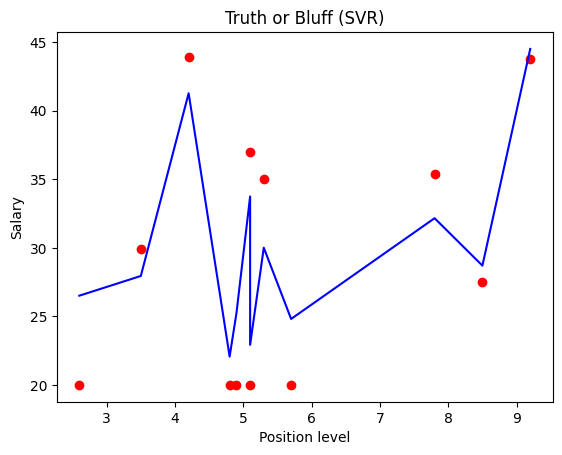

In [358]:

x_axis = sc_X.inverse_transform(X_test[:, 3:])[:, 0]

y_actual = sc_y.inverse_transform(y_test.reshape(-1, 1))
y_pred = sc_y.inverse_transform(regressor.predict(X_test).reshape(-1, 1))

x_axis = x_axis.flatten()
y_pred = y_pred.flatten()
y_actual = y_actual.flatten()

sorted_indices = np.argsort(x_axis)
x_axis_sorted = x_axis[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]


plt.scatter(x_axis, y_actual, color='red')
plt.plot(x_axis_sorted, y_pred_sorted, color='blue')

plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()
